In [2]:
### --- Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import keras
import tensorflow as tf
import h5py

### --- random state setting
seed=42

In [3]:
from google.colab import drive
drive.mount('/content/drive')
f = h5py.File('/content/drive/MyDrive/Table_TNG300_snapshot99_SubhalosProp_HaloProp.hdf5', 'r')
f.keys()


Mounted at /content/drive


<KeysViewHDF5 ['GroupPos_halo', 'M200_halo', 'Spin_halo', 'SubGroupSFR', 'SubGroupStellarPhotom_g', 'SubGroupStellarPhotom_i', 'SubGroupStellarPhotom_r', 'SubGroupStellarPhotom_z', 'SubhaloCM', 'SubhaloGrNr', 'SubhaloId', 'SubhaloMassType', 'SubhaloPos', 'b1', 'b2', 'c200_halo', 'd3_halo', 'd5_halo', 'd8_halo', 'd_minima', 'd_node', 'd_saddle_1', 'd_saddle_2', 'd_skel', 'zform_halo']>

# Preprocessing

In [4]:
GrNr = np.asarray(f['SubhaloGrNr'])
mass = np.asarray(f['SubhaloMassType'][:,4])
halo_mass = np.asarray(f['M200_halo'])
d3 = np.asarray(f['d3_halo'])
d5 = np.asarray(f['d5_halo'])
d8 = np.asarray(f['d8_halo'])
c_200= np.asarray(f['c200_halo'])
z = np.asarray(f['zform_halo'])
d_min = np.asarray(f['d_minima'])
d_node = np.asarray(f['d_node'])
d_saddle_1 = np.asarray(f['d_saddle_1'])
d_saddle_2 = np.asarray(f['d_saddle_2'])
d_skel = np.asarray(f['d_skel'])
b1 = np.asarray(f['b1'])
spin = np.asarray(f['Spin_halo'])

In [5]:
indices_cambio = np.unique(GrNr, return_index=True)[1]
mass_filtrada = mass[indices_cambio]
halo_mass_filtrada = halo_mass[indices_cambio]
d3 = d3[indices_cambio]
d5 = d5[indices_cambio]
d8 = d8[indices_cambio]
c_200= c_200[indices_cambio]
z = z[indices_cambio]
d_min = d_min[indices_cambio]
d_node = d_node[indices_cambio]
d_saddle_1 = d_saddle_1[indices_cambio]
d_saddle_2 = d_saddle_2[indices_cambio]
d_skel = d_skel[indices_cambio]
b1 = b1[indices_cambio]
spin = spin[indices_cambio]

indices_comunes=np.where((np.log10(mass_filtrada) >8.75)*(np.log10(halo_mass_filtrada) >10.5))[0]

mass_filtrada = np.log10(mass_filtrada[indices_comunes])
halo_mass_filtrada = np.log10(halo_mass_filtrada[indices_comunes])
d3 = d3[indices_comunes]
d5 = d5[indices_comunes]
d8 = d8[indices_comunes]
c_200= c_200[indices_comunes]
z = z[indices_comunes]
d_min = d_min[indices_comunes]
d_node = d_node[indices_comunes]
d_saddle_1 = d_saddle_1[indices_comunes]
d_saddle_2 = d_saddle_2[indices_comunes]
d_skel = d_skel[indices_comunes]
b1 = b1[indices_comunes]
spin = spin[indices_comunes]

/tmp/ipykernel_1138/4160979324.py:17: RuntimeWarning: invalid value encountered in log10
  indices_comunes=np.where((np.log10(mass_filtrada) >8.75)*(np.log10(halo_mass_filtrada) >10.5))[0]


In [6]:
X = np.column_stack((halo_mass_filtrada,d3, d5, d8, c_200, z, spin, d_min, d_node, d_saddle_1,d_saddle_2, d_skel))
y = b1.reshape(-1, 1)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

scaler = StandardScaler()
y_norm = scaler.fit_transform(y)

X_norm.shape, y_norm.shape

((174607, 12), (174607, 1))

In [8]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_norm,y_norm,test_size=0.3,random_state=seed)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.12, random_state=seed)
X_train.shape, X_val.shape, X_test.shape

((107557, 12), (14667, 12), (52383, 12))

# Network architecture implementation

In [9]:
### --- set backend to tensorflow, use GPU

os.environ["KERAS_BACKEND"] = "tensorflow"
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
tf.test.gpu_device_name()

Num GPUs Available:  1


'/device:GPU:0'

## 1D-ResNet50

In [10]:
### --- ResNet50
### --- https://github.com/Jun-depo/Resnet50_Conv1D/blob/master/Resnet50Conv1d_BN.py#L126

import tensorflow as tf

import keras
import keras.backend as K

from keras.utils import plot_model, to_categorical
from keras.models import Sequential, load_model
from keras.layers import Input,Activation, Dropout, Flatten, Dense, Conv1D, BatchNormalization, LSTM
from keras import regularizers

from keras.callbacks import ModelCheckpoint
from keras import metrics
from keras.optimizers import Adam

from keras.models import *
from keras.layers import *
from keras.callbacks import *
from keras.initializers import *
from keras.layers import Layer

def identity_block(X, f, filter_numbers, stage, block):
    """
    Implementation of the identity block as defined in Figure 4.

    Arguments:
    X -- input tensor of shape (m, input_length_prev (n_w), input_Channel_prev (n_c).
    f -- kernel_size, integer, shape of convolution filter in the main path.
    filter_numbers -- python list of integers, defining the number of filters in the CONV layers of the main path.
    stage -- integer, used to name the layers, depending on their position in the network.
    block -- string/character, used to name the layers, depending on their position in the network.

    Returns:
    X -- output of the identity block, tensor of shape (n_W, n_C)
    """

    # defining name basis
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'

    # Retrieve Filters
    F1, F2, F3 = filter_numbers

    # Save the input value. You'll need this later to add back to the main path.
    X_shortcut = X

    # First Conv layer
    X = Conv1D(filters = F1, kernel_size = 1, strides = 1, padding = 'valid', name = conv_name_base + '2a', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 2, name = bn_name_base + '2a')(X)
    X = Activation('relu')(X)



    # Second Conv layer
    X = Conv1D(filters = F2, kernel_size = f, strides = 1, padding = 'same', name = conv_name_base + '2b', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 2, name = bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    # Third Conv layer
    X = Conv1D(filters = F3, kernel_size = 1, strides = 1, padding = 'valid', name = conv_name_base + '2c', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 2, name = bn_name_base + '2c')(X)

    # Merge with Residual shortcut
    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)

    ### END CODE HERE ###

    return X

def convolutional_block(X, f, filters, stage, block, s = 2):
    """
    Implementation of the convolutional block as defined in Figure 4

    Arguments:
    X -- input tensor of shape (m, input_length_prev (n_w), input_Channel_prev (n_c))
    f -- integer, specifying the shape of the middle CONV's window for the main path
    filters -- python list of integers, defining the number of filters in the CONV layers of the main path
    stage -- integer, used to name the layers, depending on their position in the network
    block -- string/character, used to name the layers, depending on their position in the network
    s -- Integer, specifying the stride to be used

    Returns:
    X -- output of the convolutional block, tensor of shape (n_W, n_C)
    """

    # defining name basis
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'

    # Retrieve Filters
    F1, F2, F3 = filters

    # Save the input value
    X_shortcut = X


    ##### MAIN PATH #####
    # First component of main path
    X = Conv1D(F1, 1, strides = s, name = conv_name_base + '2a', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 2, name = bn_name_base + '2a')(X)
    X = Activation('relu')(X)

    ### START CODE HERE ###

    # Second component of main path (≈3 lines)
    X = Conv1D(F2, f, strides = 1, padding = "same", name = conv_name_base + '2b', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 2, name = bn_name_base + '2b')(X)
    X = Activation('relu')(X)

    # Third component of main path (≈2 lines)
    X = Conv1D(F3, 1, strides = 1, name = conv_name_base + '2c', kernel_initializer = glorot_uniform(seed=0))(X)
    #X = BatchNormalization(axis = 2, name = bn_name_base + '2c')(X)

    ##### SHORTCUT PATH #### (≈2 lines)
    X_shortcut = Conv1D(F3, 1, strides = s, name = conv_name_base + '1', kernel_initializer = glorot_uniform(seed=0))(X_shortcut)
    #X_shortcut = BatchNormalization(axis = 2, name = bn_name_base + '1')(X_shortcut)

    # Final step: Add shortcut value to main path, and pass it through a RELU activation (≈2 lines)
    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)

    ### END CODE HERE ###

    return X

def ResNet50(input_shape = (30000, 1), max_pool_s=10, max_strides=5, kernel_size=3, strides = 2, f=3, ave_pool_size=5, n_out=1, i=None):
    """
    Implementation of the popular ResNet50 the following architecture:
    CONV1D -> BATCHNORM -> RELU -> MAXPOOL -> CONVBLOCK -> IDBLOCK*2 -> CONVBLOCK -> IDBLOCK*3
    -> CONVBLOCK -> IDBLOCK*5 -> CONVBLOCK -> IDBLOCK*2 -> AVGPOOL -> TOPLAYER

    Arguments:
    input_shape -- shape of the 1D data
    n_out -- integer, number of classes or output

    Returns:
    model -- a Model() instance in Keras

    params here were used in one of my projects.
    """

    # Define the input as a tensor with shape input_shape
    X_input = Input(input_shape)
    X = MaxPooling1D(max_pool_s, max_strides)(X_input)

    # Zero-Padding
    X = ZeroPadding1D(3)(X)

    # stage 1, 64 filters, kernel_size=7
    X = Conv1D(64, kernel_size, strides=1, name = 'conv1', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 2, name = 'bn_conv1')(X)
    X = Activation('relu')(X)
    X = MaxPooling1D(3, strides=2)(X)

    # Stage 2
    X = convolutional_block(X, f, filters = [16, 16, 64], stage = 2, block='a', s = 1)
    X = identity_block(X, f, [16, 16, 64], stage=2, block='b')
    X = identity_block(X, f, [16, 16, 64], stage=2, block='c')

    ### START CODE HERE ###

    X = convolutional_block(X, f, filters = [32,32,128], stage = 3, block='a', s = 2)
    X = identity_block(X, f, [32,32,128], stage=3, block='b')
    X = identity_block(X, f, [32,32,128], stage=3, block='c')
    X = identity_block(X, f, [32,32,128], stage=3, block='d')

    # Stage 4 (≈6 lines)

    X = convolutional_block(X, f, filters = [64, 64, 256], stage = 4, block='a', s = 2)
    X = identity_block(X, f, [64, 64, 256], stage=4, block='b')
    X = identity_block(X, f, [64, 64, 256], stage=4, block='c')
    X = identity_block(X, f, [64, 64, 256], stage=4, block='d')
    X = identity_block(X, f, [64, 64, 256], stage=4, block='e')
    X = identity_block(X, f, [64, 64, 256], stage=4, block='f')

    # Stage 5

    X = convolutional_block(X, f, filters = [64, 64, 256], stage = 5, block='a', s = 2)
    X = identity_block(X, f, [64, 64, 256], stage=5, block='b')
    X = identity_block(X, f, [64, 64, 256], stage=5, block='c')

    X = AveragePooling1D(ave_pool_size)(X)

    X = Dropout(0.5)(X)

    # For regression
    X = Dense(n_out, name='fc-dense-2', kernel_initializer = glorot_uniform(seed=0),
              kernel_regularizer=regularizers.l2(0.2), bias_regularizer=regularizers.l2(0.2))(X)

    # for classification, if n_out =1, add:
    # X = Activation('sigmoid')(X)

    # for classification, if n_out > 1, add:
    # X = Activation('softmax')(X)

    # Create model
    model = Model(inputs = X_input, outputs = X, name=f'ResNet50_1d_{i}')

    return model

## Model training

In [11]:
lr = 1e-4
optim = Adam(learning_rate=lr)

### --- use GPU for training
with tf.device('/device:GPU:0'):
  models = []
  input = keras.layers.Input(shape=(X_train.shape[1],1))
  model = ResNet50(
        input_shape=(X_train.shape[1],1),
        max_pool_s=1,
        strides=1,
        f=2,
        max_strides=1,
        ave_pool_size=1
    )
  model.compile(
      loss = "mse",
      optimizer = optim,
      #metrics = metrics
  )


In [12]:
# Create checkpoint file
!touch Resnet50Conv1d.keras

In [14]:
batch_size=512
epochs=200

checkpointer = ModelCheckpoint(
    './Resnet50Conv1d.keras',
    verbose=1,
    save_best_only=True
)

history = model.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    callbacks=[checkpointer],
    validation_data=(X_val, y_val)
)

Epoch 1/200
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 31.6282
Epoch 1: val_loss improved from None to 1.59990, saving model to ./Resnet50Conv1d.keras

Epoch 1: finished saving model to ./Resnet50Conv1d.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 108s 191ms/step - loss: 20.8960 - val_loss: 1.5999
Epoch 2/200
210/211 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 8.2030
Epoch 2: val_loss improved from 1.59990 to 1.41916, saving model to ./Resnet50Conv1d.keras

Epoch 2: finished saving model to ./Resnet50Conv1d.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 7.1552 - val_loss: 1.4192
Epoch 3/200
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 4.7392
Epoch 3: val_loss improved from 1.41916 to 1.36211, saving model to ./Resnet50Conv1d.keras

Epoch 3: finished saving model to ./Resnet50Conv1d.keras
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 4.3738 - val_loss: 1.3621
Epoch 4/200
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 3.5414
Epoch 4: val_loss improved from 1.36211 to 1.2

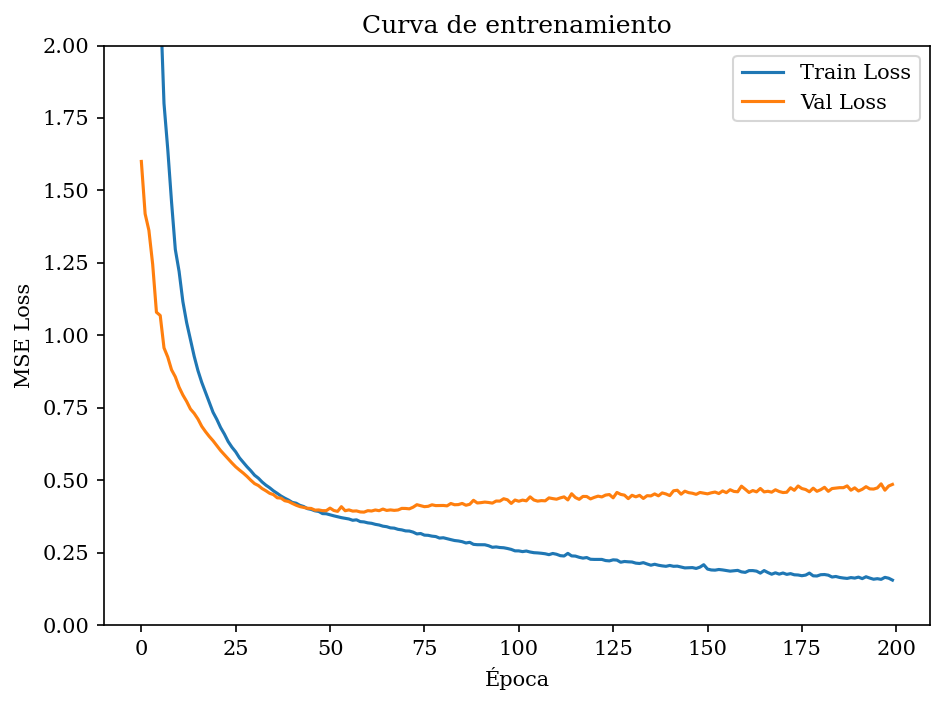

In [15]:
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "DejaVu Serif"
plt.rcParams["mathtext.it"] = "DejaVu Serif:italic"
plt.rcParams["mathtext.bf"] = "DejaVu Serif:bold"
fig, ax = plt.subplots(dpi=150)
ax.plot(history.history['loss'], label='Train Loss')
ax.plot(history.history['val_loss'], label='Val Loss')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss')
ax.set_title('Curva de entrenamiento')
ax.legend()
ax.set_ylim(0,2)
plt.tight_layout()
plt.show()

In [16]:
### --- evaluate model
best_model = load_model("Resnet50Conv1d.keras")

In [17]:
scaler_y = StandardScaler()
y_norm = scaler_y.fit_transform(y)

In [18]:
from scipy import stats
from sklearn.metrics import mean_squared_error
from scipy.stats import wasserstein_distance

# Predicciones
y_pred_norm = model.predict(X_test)

# Aplanar de (samples, steps, 1) -> (samples, 1)
y_pred_norm = y_pred_norm.reshape(y_pred_norm.shape[0], -1)

# Desnormalizar
y_test_NN_numpy = scaler_y.inverse_transform(y_test).flatten()
y_pred_NN_numpy = scaler_y.inverse_transform(y_pred_norm).flatten()

# PCC
pcc, pcc_pval = stats.pearsonr(y_test_NN_numpy, y_pred_NN_numpy)
print(f"PCC:  r = {pcc:.4f}  (p = {pcc_pval:.2e})")

# K-S Test
ks_stat, ks_pval = stats.ks_2samp(y_test_NN_numpy, y_pred_NN_numpy)
print(f"K-S:  D = {ks_stat:.4f}  (p = {ks_pval:.2e})")

# Wassertein Distance
wd = wasserstein_distance(y_test_NN_numpy, y_pred_NN_numpy)
print("WD:", wd)

1637/1637 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step
PCC:  r = 0.7314  (p = 0.00e+00)
K-S:  D = 0.0696  (p = 1.02e-110)
WD: 0.20494017957865704


In [19]:
from scipy.stats import gaussian_kde

# Densidad por punto para el colormap
xy = np.vstack([y_test_NN_numpy, y_pred_NN_numpy])
z_NN = gaussian_kde(xy)(xy)

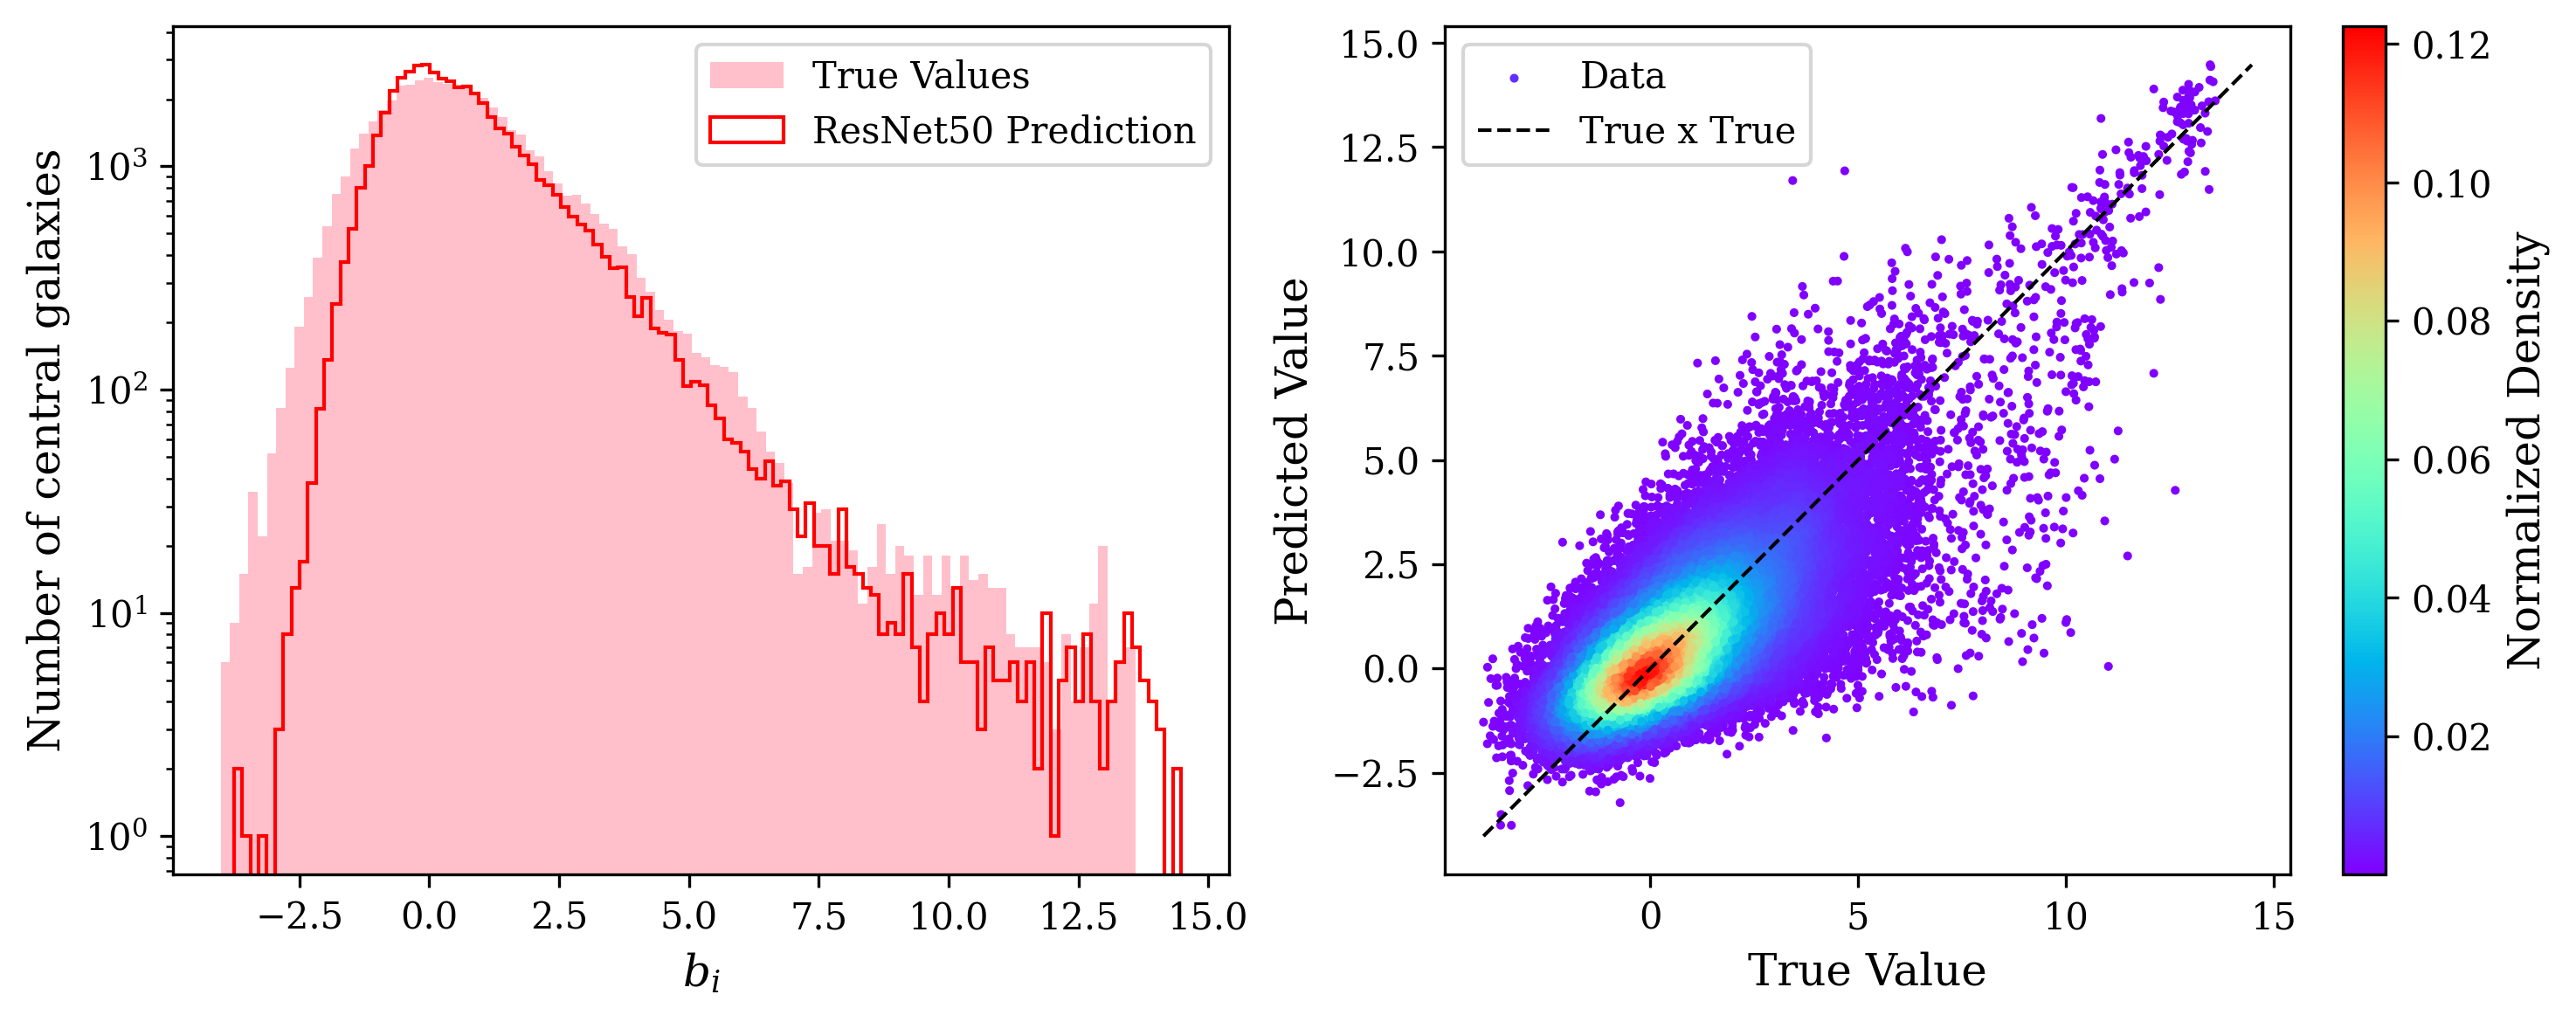

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=300)

# Histograma
axs[0].hist(y_test_NN_numpy, bins='scott', label='True Values', color='pink')
axs[0].hist(y_pred_NN_numpy, bins='scott', label='ResNet50 Prediction', histtype='step', color='red')
axs[0].set_yscale('log')
axs[0].set_xlabel('$b_i$', fontsize=12)
axs[0].set_ylabel('Number of central galaxies', fontsize=12)
axs[0].legend()

# Scatter
scatter_NN = axs[1].scatter(y_test_NN_numpy, y_pred_NN_numpy, c=z_NN, s=2, cmap='rainbow', label='Data')
cb = fig.colorbar(scatter_NN, ax=axs[1], label='Normalized Density')
cb.set_label('Normalized Density', fontsize=12)
min_val_NN = min(min(y_test_NN_numpy), min(y_pred_NN_numpy))
max_val_NN = max(max(y_test_NN_numpy), max(y_pred_NN_numpy))
axs[1].plot([min_val_NN, max_val_NN], [min_val_NN, max_val_NN],
            linewidth=1, linestyle='--', color='black', label='True x True')
axs[1].set_ylabel('Predicted Value', fontsize=12)
axs[1].set_xlabel('True Value', fontsize=12)
axs[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('resnetperformance_horizontal.png')
plt.show()

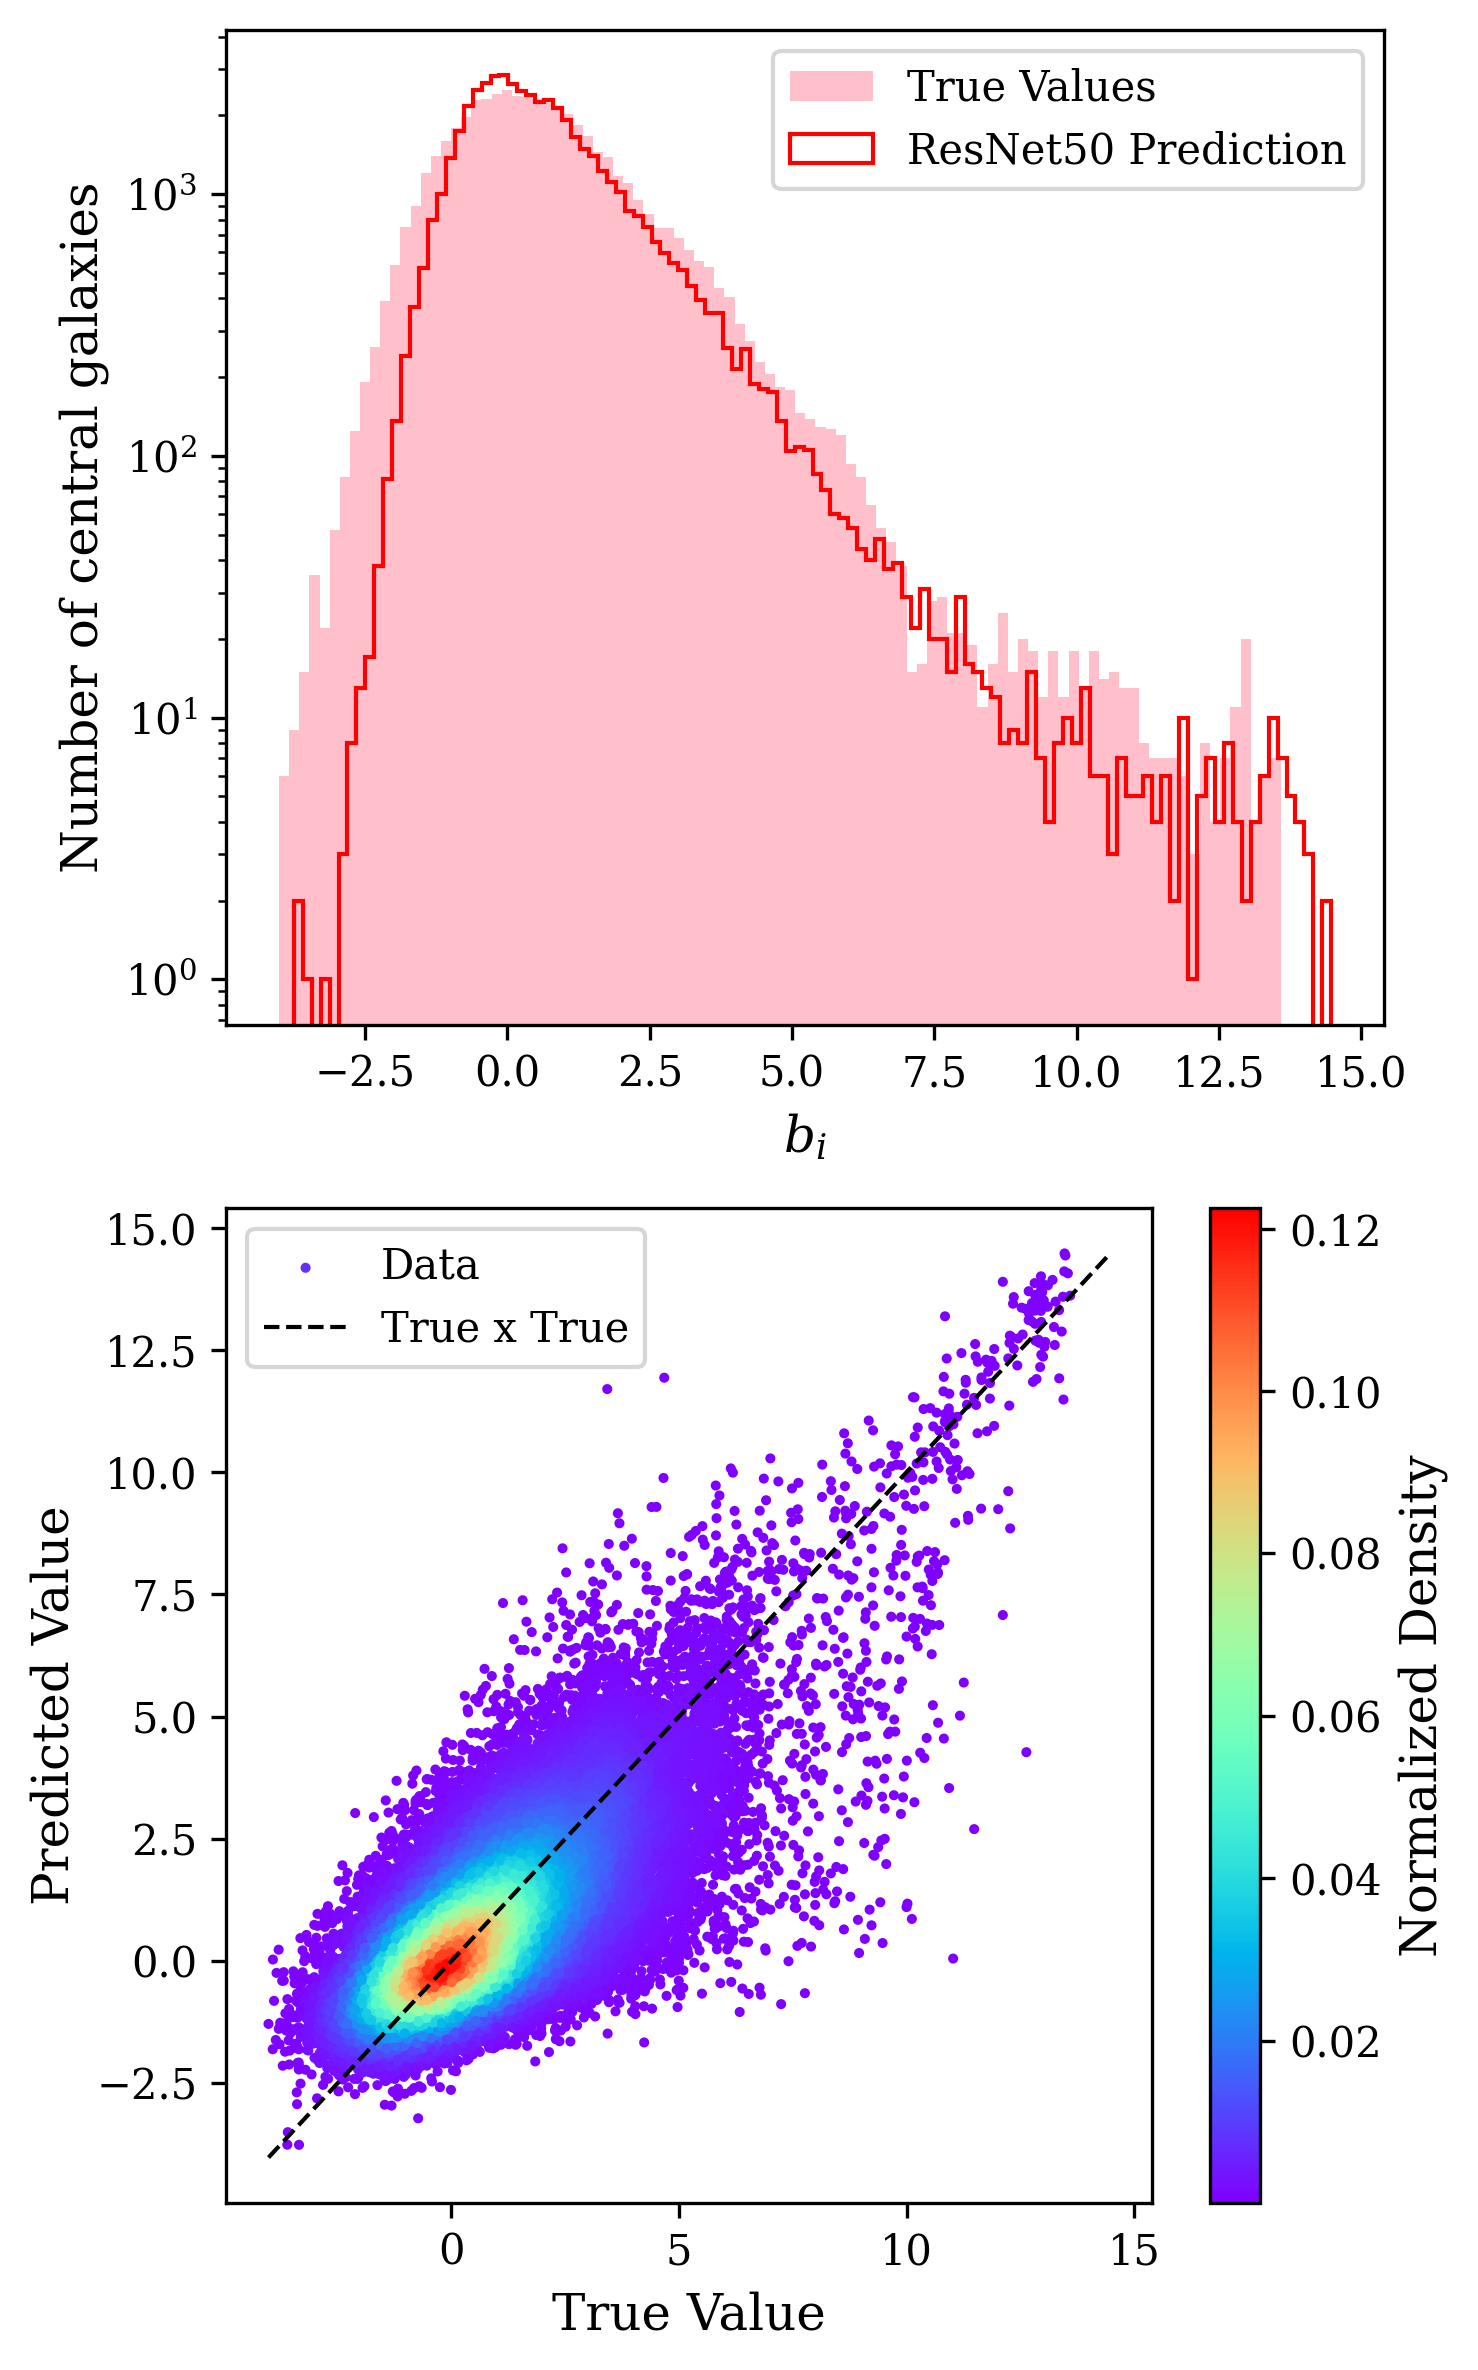

In [21]:
fig, axs = plt.subplots(2, 1, figsize=(5, 8), dpi=300)

# Histograma (top subplot)
axs[0].hist(y_test_NN_numpy, bins='scott', label='True Values', color='pink')
axs[0].hist(y_pred_NN_numpy, bins='scott', label='ResNet50 Prediction', histtype='step', color='red')
axs[0].set_yscale('log')
axs[0].set_xlabel('$b_i$', fontsize=12)
axs[0].set_ylabel('Number of central galaxies', fontsize=12)
axs[0].legend()

# Scatter plot (bottom subplot)
scatter_NN = axs[1].scatter(y_test_NN_numpy, y_pred_NN_numpy, c=z_NN, s=2, cmap='rainbow', label='Data')
cb = fig.colorbar(scatter_NN, ax=axs[1], label='Normalized Density')
cb.set_label('Normalized Density', fontsize=12)
min_val_NN = min(min(y_test_NN_numpy), min(y_pred_NN_numpy))
max_val_NN = max(max(y_test_NN_numpy), max(y_pred_NN_numpy))
axs[1].plot([min_val_NN, max_val_NN], [min_val_NN, max_val_NN],
            linewidth=1, linestyle='--', color='black', label='True x True')
axs[1].set_ylabel('Predicted Value', fontsize=12)
axs[1].set_xlabel('True Value', fontsize=12)
axs[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('resnetperformance_vertical.png')
plt.show()

In [22]:
### --- save model
model.save('GalaxyBiasResNet.keras')